<a href="https://colab.research.google.com/github/jittz3711-ops/multimodel-fraud-detection-using-gnn-and-tbp/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import files
import io, pandas as pd

print("Upload your transactions.csv file")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"Loaded: {filename}")
print(f"Shape : {df.shape}")
df.head(3)

Upload your transactions.csv file


Saving transactions.csv to transactions (1).csv
Loaded: transactions (1).csv
Shape : (100000, 12)


,transaction_id,account_id,merchant_id,amount,timestamp,merchant_category,device_type,country,is_fraud,balance_diff_orig,balance_diff_dest,amount_to_balance_ratio
0,0,C1364834432,C112352648,468120.16,2024-01-13 16:00:00,atm,pos,US,0,0.0,468120.16,4.681202e+11
1,1,C1054357434,C302256535,39333.80,2024-01-12 17:00:00,atm,pos,US,0,0.0,39333.80,3.933380e+10
2,2,C1126776883,M2111082372,2017.48,2024-01-13 14:00:00,retail,web,SG,0,0.0,0.00,2.017480e+09


In [9]:
import torch
print(f"PyTorch version: {torch.__version__}")

# Install PyTorch Geometric correctly for your torch version
!pip install torch-geometric -q

# Install dependencies matching your exact torch+cuda version
!pip install pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv \
    -f https://data.pyg.org/whl/torch-2.3.0+cu121.html -q

print("Done! Now restart runtime: Runtime → Restart session")

PyTorch version: 2.10.0+cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 95.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 96.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.6/949.6 kB 54.2 MB/s eta 0:00:00
Done! Now restart runtime: Runtime → Restart session


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, SAGEConv, BatchNorm
from torch_geometric.utils import add_self_loops
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

CONFIG = {
    'test_size': 0.2, 'val_size': 0.1,
    'hidden_dim': 128, 'num_heads': 4, 'dropout': 0.3,
    'lr': 0.001, 'weight_decay': 1e-4,
    'epochs': 100, 'patience': 15, 'sample_size': 100000,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}
print(f"Device : {CONFIG['device']}")
print(f"PyTorch: {torch.__version__}")

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/libpyg.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sp

Device : cpu
PyTorch: 2.10.0+cpu


In [11]:
class BehaviourProfiler:
    def fit_transform(self, df):
        df = df.copy()
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values(['account_id','timestamp'])
        df['hour']        = df['timestamp'].dt.hour
        df['day_of_week'] = df['timestamp'].dt.dayofweek
        df['is_weekend']  = df['day_of_week'].isin([5,6]).astype(int)
        df['is_night']    = df['hour'].apply(lambda h: 1 if h<6 or h>22 else 0)
        acc = df.groupby('account_id').agg(
            acc_avg_amount=('amount','mean'),
            acc_std_amount=('amount','std'),
            acc_max_amount=('amount','max'),
            acc_tx_count=('transaction_id','count'),
            acc_unique_merchants=('merchant_id','nunique'),
            acc_unique_countries=('country','nunique'),
            acc_night_ratio=('is_night','mean'),
            acc_weekend_ratio=('is_weekend','mean'),
        ).reset_index()
        acc['acc_std_amount'] = acc['acc_std_amount'].fillna(0)
        df = df.merge(acc, on='account_id', how='left')
        df['amount_zscore']  = (df['amount']-df['acc_avg_amount'])/(df['acc_std_amount']+1e-6)
        df['tx_rank']        = df.groupby('account_id').cumcount()
        df['velocity_score'] = df['tx_rank']/(df['acc_tx_count']+1)
        return df
    def get_feature_columns(self):
        return ['amount','hour','day_of_week','is_weekend','is_night',
                'acc_avg_amount','acc_std_amount','acc_max_amount',
                'acc_tx_count','acc_unique_merchants','acc_unique_countries',
                'acc_night_ratio','acc_weekend_ratio','amount_zscore','velocity_score',
                'balance_diff_orig','balance_diff_dest','amount_to_balance_ratio']

print('Running behaviour profiling...')
profiler = BehaviourProfiler()
df = profiler.fit_transform(df)
feature_cols = profiler.get_feature_columns()
print(f'Done! {len(feature_cols)} features engineered')
df[feature_cols].head(3)

Running behaviour profiling...
Done! 18 features engineered


,amount,hour,day_of_week,is_weekend,is_night,acc_avg_amount,acc_std_amount,acc_max_amount,acc_tx_count,acc_unique_merchants,acc_unique_countries,acc_night_ratio,acc_weekend_ratio,amount_zscore,velocity_score,balance_diff_orig,balance_diff_dest,amount_to_balance_ratio
0,516459.01,0,1,0,1,516459.01,0.0,516459.01,1,1,1,1.0,0.0,0.0,0.0,-153435.60,516459.01,3.365966
1,17686.93,14,5,1,0,17686.93,0.0,17686.93,1,1,1,0.0,1.0,0.0,0.0,-17686.94,0.00,0.169874
2,16669.78,17,6,1,0,16669.78,0.0,16669.78,1,1,1,0.0,1.0,0.0,0.0,-16669.78,0.00,0.070297


In [12]:
import pandas as pd
df = pd.read_csv('transactions.csv')
print("Loaded 'transactions.csv' into DataFrame 'df'.")
display(df.head())

Loaded 'transactions.csv' into DataFrame 'df'.


,transaction_id,account_id,merchant_id,amount,timestamp,merchant_category,device_type,country,is_fraud,balance_diff_orig,balance_diff_dest,amount_to_balance_ratio
0,0,C1364834432,C112352648,468120.16,2024-01-13 16:00:00,atm,pos,US,0,0.00,468120.16,4.681202e+11
1,1,C1054357434,C302256535,39333.80,2024-01-12 17:00:00,atm,pos,US,0,0.00,39333.80,3.933380e+10
2,2,C1126776883,M2111082372,2017.48,2024-01-13 14:00:00,retail,web,SG,0,0.00,0.00,2.017480e+09
3,3,C2088073298,C305827266,185360.25,2024-01-08 21:00:00,atm,pos,US,0,-7910.00,185360.25,2.343366e+01
4,4,C755566099,C1599740311,198845.02,2024-01-16 11:00:00,retail,pos,US,0,198845.02,-198845.03,9.484618e+00


In [13]:
class BehaviourProfiler:
    def fit_transform(self, df):
        df = df.copy()
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values(['account_id','timestamp'])
        df['hour']        = df['timestamp'].dt.hour
        df['day_of_week'] = df['timestamp'].dt.dayofweek
        df['is_weekend']  = df['day_of_week'].isin([5,6]).astype(int)
        df['is_night']    = df['hour'].apply(lambda h: 1 if h<6 or h>22 else 0)
        acc = df.groupby('account_id').agg(
            acc_avg_amount=('amount','mean'),
            acc_std_amount=('amount','std'),
            acc_max_amount=('amount','max'),
            acc_tx_count=('transaction_id','count'),
            acc_unique_merchants=('merchant_id','nunique'),
            acc_unique_countries=('country','nunique'),
            acc_night_ratio=('is_night','mean'),
            acc_weekend_ratio=('is_weekend','mean'),
        ).reset_index()
        acc['acc_std_amount'] = acc['acc_std_amount'].fillna(0)
        df = df.merge(acc, on='account_id', how='left')
        df['amount_zscore']  = (df['amount']-df['acc_avg_amount'])/(df['acc_std_amount']+1e-6)
        df['tx_rank']        = df.groupby('account_id').cumcount()
        df['velocity_score'] = df['tx_rank']/(df['acc_tx_count']+1)
        return df
    def get_feature_columns(self):
        return ['amount','hour','day_of_week','is_weekend','is_night',
                'acc_avg_amount','acc_std_amount','acc_max_amount',
                'acc_tx_count','acc_unique_merchants','acc_unique_countries',
                'acc_night_ratio','acc_weekend_ratio','amount_zscore','velocity_score',
                'balance_diff_orig','balance_diff_dest','amount_to_balance_ratio']

print('Running behaviour profiling...')
profiler = BehaviourProfiler()
df = profiler.fit_transform(df)
feature_cols = profiler.get_feature_columns()
print(f'Done! {len(feature_cols)} features engineered')
df[feature_cols].head(3)

Running behaviour profiling...
Done! 18 features engineered


,amount,hour,day_of_week,is_weekend,is_night,acc_avg_amount,acc_std_amount,acc_max_amount,acc_tx_count,acc_unique_merchants,acc_unique_countries,acc_night_ratio,acc_weekend_ratio,amount_zscore,velocity_score,balance_diff_orig,balance_diff_dest,amount_to_balance_ratio
0,516459.01,0,1,0,1,516459.01,0.0,516459.01,1,1,1,1.0,0.0,0.0,0.0,-153435.60,516459.01,3.365966
1,17686.93,14,5,1,0,17686.93,0.0,17686.93,1,1,1,0.0,1.0,0.0,0.0,-17686.94,0.00,0.169874
2,16669.78,17,6,1,0,16669.78,0.0,16669.78,1,1,1,0.0,1.0,0.0,0.0,-16669.78,0.00,0.070297


In [14]:
def build_graph(df, feature_cols):
    n = len(df)
    df = df.reset_index(drop=True)
    le = LabelEncoder()
    for col in ['merchant_category','device_type','country']:
        df[col+'_enc'] = le.fit_transform(df[col].astype(str))
    all_cols = list(dict.fromkeys(feature_cols+['merchant_category_enc','device_type_enc','country_enc']))
    X = StandardScaler().fit_transform(df[all_cols].fillna(0).values)
    x = torch.tensor(X, dtype=torch.float)
    print('Building edges (shared account / merchant)...')
    edges = []
    for _, g in df.groupby('account_id'):
        idx = g.index.tolist()
        for i in range(len(idx)):
            for j in range(i+1, min(i+6,len(idx))):
                edges += [(idx[i],idx[j]),(idx[j],idx[i])]
    for _, g in df.groupby('merchant_id'):
        idx = g.index.tolist()
        for i in range(len(idx)):
            for j in range(i+1, min(i+4,len(idx))):
                edges += [(idx[i],idx[j]),(idx[j],idx[i])]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_index, _ = add_self_loops(edge_index, num_nodes=n)
    y = torch.tensor(df['is_fraud'].values, dtype=torch.long)
    idx = np.arange(n)
    tr,te = train_test_split(idx, test_size=0.2, stratify=df['is_fraud'].values, random_state=42)
    tr,va = train_test_split(tr,  test_size=0.125, stratify=df['is_fraud'].values[tr], random_state=42)
    tm=torch.zeros(n,dtype=torch.bool); tm[tr]=True
    vm=torch.zeros(n,dtype=torch.bool); vm[va]=True
    em=torch.zeros(n,dtype=torch.bool); em[te]=True
    data = Data(x=x, edge_index=edge_index, y=y, train_mask=tm, val_mask=vm, test_mask=em)
    print(f'Graph: {data.num_nodes:,} nodes | {data.num_edges:,} edges | {x.shape[1]} features')
    return data

data = build_graph(df, feature_cols)

Building edges (shared account / merchant)...
Graph: 100,000 nodes | 116,278 edges | 21 features


In [15]:
class MultimodalFraudGNN(nn.Module):
    def __init__(self, in_channels, hidden_dim=128, num_heads=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.gat1  = GATConv(in_channels, hidden_dim//num_heads, heads=num_heads, dropout=dropout, concat=True)
        self.gat2  = GATConv(hidden_dim,  hidden_dim//num_heads, heads=num_heads, dropout=dropout, concat=True)
        self.sage1 = SAGEConv(in_channels, hidden_dim)
        self.sage2 = SAGEConv(hidden_dim,  hidden_dim)
        self.bn_gat1  = BatchNorm(hidden_dim)
        self.bn_gat2  = BatchNorm(hidden_dim)
        self.bn_sage1 = BatchNorm(hidden_dim)
        self.bn_sage2 = BatchNorm(hidden_dim)
        self.fusion     = nn.Linear(hidden_dim*2, hidden_dim)
        self.bn_fuse    = nn.BatchNorm1d(hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, 2))
    def forward(self, x, edge_index):
        g = F.dropout(x, p=self.dropout, training=self.training)
        g = F.elu(self.bn_gat1(self.gat1(g, edge_index)))
        g = F.dropout(g, p=self.dropout, training=self.training)
        g = F.elu(self.bn_gat2(self.gat2(g, edge_index)))
        s = F.relu(self.bn_sage1(self.sage1(x, edge_index)))
        s = F.dropout(s, p=self.dropout, training=self.training)
        s = F.relu(self.bn_sage2(self.sage2(s, edge_index)))
        fused = torch.cat([g, s], dim=-1)
        fused = F.relu(self.bn_fuse(self.fusion(fused)))
        fused = F.dropout(fused, p=self.dropout, training=self.training)
        return self.classifier(fused)

device = CONFIG['device']
model  = MultimodalFraudGNN(data.x.shape[1], CONFIG['hidden_dim'], CONFIG['num_heads'], CONFIG['dropout']).to(device)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model ready | {params:,} parameters | Device: {device}')
print(model)

Model ready | 100,802 parameters | Device: cpu
MultimodalFraudGNN(
  (gat1): GATConv(21, 32, heads=4)
  (gat2): GATConv(128, 32, heads=4)
  (sage1): SAGEConv(21, 128, aggr=mean)
  (sage2): SAGEConv(128, 128, aggr=mean)
  (bn_gat1): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn_gat2): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn_sage1): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn_sage2): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fusion): Linear(in_features=256, out_features=128, bias=True)
  (bn_fuse): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [16]:
counts  = torch.bincount(data.y)
weights = (1.0/counts.float())
weights = (weights/weights.sum()*len(counts)).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

best_auc, patience_cnt, best_state = 0, 0, None
history = {'loss':[], 'val_auc':[], 'val_ap':[]}

print('Training...\n' + '-'*50)
for epoch in range(1, CONFIG['epochs']+1):
    model.train(); optimizer.zero_grad()
    out  = model(data.x.to(device), data.edge_index.to(device))
    loss = criterion(out[data.train_mask], data.y[data.train_mask].to(device))
    loss.backward(); optimizer.step()
    model.eval()
    with torch.no_grad():
        out  = model(data.x.to(device), data.edge_index.to(device))
        prob = F.softmax(out, dim=1)[:,1].cpu().numpy()
        y    = data.y.cpu().numpy()
        val_auc = roc_auc_score(y[data.val_mask], prob[data.val_mask])
        val_ap  = average_precision_score(y[data.val_mask], prob[data.val_mask])
    history['loss'].append(loss.item())
    history['val_auc'].append(val_auc)
    history['val_ap'].append(val_ap)
    scheduler.step(val_auc)
    if val_auc > best_auc:
        best_auc = val_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_cnt = 0
    else:
        patience_cnt += 1
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Loss: {loss.item():.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}')
    if patience_cnt >= CONFIG['patience']:
        print(f'Early stopping at epoch {epoch}'); break
model.load_state_dict(best_state)
print(f'\nBest Val AUC: {best_auc:.4f}')

Training...
--------------------------------------------------
Epoch  10 | Loss: 0.4285 | Val AUC: 0.9729 | Val AP: 0.4070
Epoch  20 | Loss: 0.2922 | Val AUC: 0.9720 | Val AP: 0.5249
Early stopping at epoch 29

Best Val AUC: 0.9780


In [17]:
# Cell 9 — Test Evaluation
model.eval()
with torch.no_grad():
    out = model(data.x.to(device), data.edge_index.to(device))
    test_prob = F.softmax(out, dim=1)[:,1].cpu().numpy()
    test_pred = out.argmax(dim=1).cpu().numpy()
    test_true = data.y.cpu().numpy()

mask = data.test_mask.numpy()
print('='*55 + '\nTEST RESULTS\n' + '='*55)
print(f"ROC-AUC  : {roc_auc_score(test_true[mask], test_prob[mask]):.4f}")
print(f"Avg Prec : {average_precision_score(test_true[mask], test_prob[mask]):.4f}")
print()
print(classification_report(test_true[mask], test_pred[mask], target_names=['Legit','Fraud']))

TEST RESULTS
ROC-AUC  : 0.9819
Avg Prec : 0.5775

              precision    recall  f1-score   support

       Legit       1.00      0.89      0.94     19974
       Fraud       0.01      0.96      0.02        26

    accuracy                           0.89     20000
   macro avg       0.51      0.92      0.48     20000
weighted avg       1.00      0.89      0.94     20000



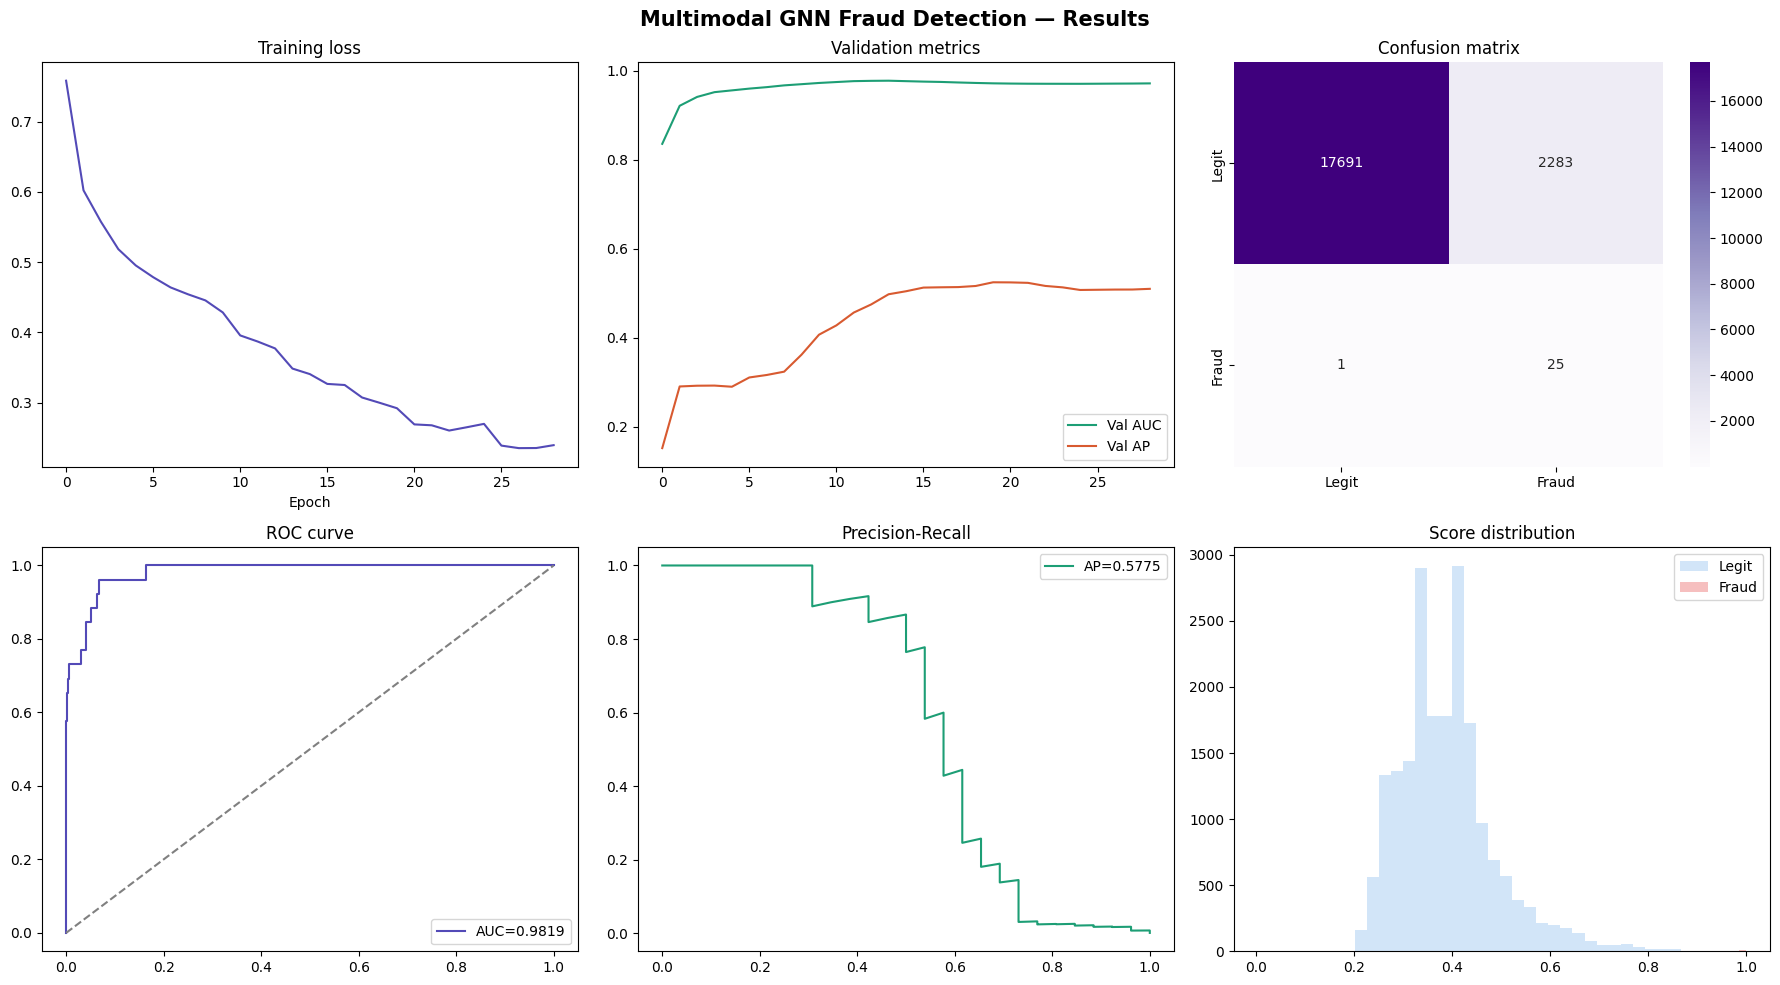

Plot saved!


In [18]:
# Cell 10 — Visualise Results
mask = data.test_mask.numpy()
y_t  = test_true[mask]; y_p = test_pred[mask]; y_pr = test_prob[mask]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Multimodal GNN Fraud Detection — Results', fontsize=15, fontweight='bold')

axes[0,0].plot(history['loss'], color='#534AB7')
axes[0,0].set_title('Training loss'); axes[0,0].set_xlabel('Epoch')

axes[0,1].plot(history['val_auc'], label='Val AUC', color='#1D9E75')
axes[0,1].plot(history['val_ap'],  label='Val AP',  color='#D85A30')
axes[0,1].set_title('Validation metrics'); axes[0,1].legend()

cm = confusion_matrix(y_t, y_p)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0,2],
    xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
axes[0,2].set_title('Confusion matrix')

fpr, tpr, _ = roc_curve(y_t, y_pr)
axes[1,0].plot(fpr, tpr, color='#534AB7', label=f"AUC={roc_auc_score(y_t,y_pr):.4f}")
axes[1,0].plot([0,1],[0,1],'--',color='gray')
axes[1,0].set_title('ROC curve'); axes[1,0].legend()

prec, rec, _ = precision_recall_curve(y_t, y_pr)
axes[1,1].plot(rec, prec, color='#1D9E75', label=f"AP={average_precision_score(y_t,y_pr):.4f}")
axes[1,1].set_title('Precision-Recall'); axes[1,1].legend()

axes[1,2].hist(y_pr[y_t==0], bins=40, alpha=0.6, label='Legit', color='#B5D4F4')
axes[1,2].hist(y_pr[y_t==1], bins=40, alpha=0.6, label='Fraud', color='#F09595')
axes[1,2].set_title('Score distribution'); axes[1,2].legend()

plt.tight_layout()
plt.savefig('fraud_gnn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

In [19]:
import torch

# Save the trained model
torch.save(model.state_dict(), 'fraud_model.pth')

# Also save the scaler and profiler info
import pickle
pickle.dump(profiler, open('profiler.pkl', 'wb'))

In [20]:
import pickle
import torch
from google.colab import files

# Save model
print("Saving model...")
torch.save(model.state_dict(), 'fraud_model.pth')
print("Model saved!")

# Save inference data
print("Saving inference data...")
inference_data = {
    'scaler_mean'         : scaler.mean_,
    'scaler_std'          : scaler.scale_,
    'le_merchant_classes' : le_merchant.classes_,
    'le_device_classes'   : le_device.classes_,
    'le_country_classes'  : le_country.classes_,
}
with open('inference_data.pkl', 'wb') as f:
    pickle.dump(inference_data, f)
print("Inference data saved!")

# Download both files
print("Downloading...")
files.download('fraud_model.pth')
files.download('inference_data.pkl')

print("=" * 40)
print("DONE! Move files to backend folder")
print("=" * 40)


Saving model...
Model saved!
Saving inference data...
Inference data saved!
Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DONE! Move files to backend folder
